# 02 — Train sampled NES

Run one experiment, save it as JSON, then plot/read it in notebook 03.

In [18]:
import time
import jax
import jax.numpy as jnp

print("JAX backend:", jax.default_backend())
print("JAX devices:", jax.devices())

# Force the array onto the first GPU if available
device = jax.devices("gpu")[0]

x = jax.device_put(jnp.ones((5000, 5000)), device)

t0 = time.time()
y = x @ x
y.block_until_ready()
t1 = time.time()

print("result device:", y.device)
print("backend used:", y.device.platform)
print("time:", round(t1 - t0, 3), "s")

JAX backend: gpu
JAX devices: [CudaDevice(id=0)]
result device: cuda:0
backend used: gpu
time: 0.004 s


In [19]:
import sys
from pathlib import Path


PROJECT_ROOT = Path.home() / "Desktop" / "Master Thesis" / "nes_lattice_project"
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from nes_lattice.train import TrainConfig, train, save_history


In [ ]:
# Example A: 1D TFIM, k=2, FFN. Good first sanity check.
cfg = TrainConfig(
    shape=(10,),
    hamiltonian="tfim",
    k=2,
    g=1.0,
    model="ffn",
    hidden=(128, 128),
    steps=500,
    lr=2e-3,
    n_chains=64,
    n_samples=8,
    print_every=100,
    seed=0,
)

params, history = train(cfg)

results_dir = PROJECT_ROOT / "results"
results_dir.mkdir(parents=True, exist_ok=True)
save_path = results_dir / "sampled_nes_1d_tfim_L10_k2_ffn.json"
save_history(history, save_path, cfg)
print("saved to:", save_path)


In [21]:
# Example B: 2D TFIM, CNN.
cfg = TrainConfig(
    shape=(4, 4),
    hamiltonian="tfim",
    k=2,
    g=1.0,
    model="cnn",
    channels=(16, 16),
    steps=8000,
    lr=2e-3,
    n_chains=64,
    n_samples=8,
    print_every=100,
    seed=1,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / "results" / "sampled_nes_2d_tfim_4x4_k2_cnn.json"
save_history(history, save_path, cfg)

print("saved to:", save_path)


{'step': 0, 'loss_sum': -33.95357507544875, 'train_energy_estimator': nan, 'energies': [-17.953574447504067, -16.00000062794468], 'reference': [-34.01059755084618, -34.010596999468305], 'reference_source': 'netket_lanczos_ed', 'abs_errors': [16.05702310334211, 18.010596371523626], 'trace_error': 34.06761947486573, 'condition_number_S': 1640595.1387873439, 'sampler_accept_rate': nan, 'grad_norm': nan, 'eval': {'method': 'exact_span', 'accept_rate': None}}
{'step': 100, 'loss_sum': -33.988286546027425, 'train_energy_estimator': -33.890604769811034, 'energies': [-17.990059158860262, -15.998227387167159], 'reference': [-34.01059755084618, -34.010596999468305], 'reference_source': 'netket_lanczos_ed', 'abs_errors': [16.020538391985916, 18.012369612301146], 'trace_error': 34.03290800428705, 'condition_number_S': 8.29013591296691, 'sampler_accept_rate': 0.71435546875, 'grad_norm': 0.5211801528930664, 'eval': {'method': 'exact_span', 'accept_rate': None}}
{'step': 200, 'loss_sum': -38.40127576

In [2]:
# Example C: 2D TFIM, RBM.
cfg = TrainConfig(
    shape=(4, 4),
    hamiltonian="tfim",
    k=4,
    g=1.0,
    model="rbm",
    rbm_hidden=64,
    steps=2500,
    lr=1e-3,
    n_chains=64,
    n_samples=8,
    print_every=100,
    seed=2,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / "results" / "sampled_nes_2d_tfim_4x4_k2_rbm.json"
save_history(history, save_path, cfg)

print("saved to:", save_path)


E0617 15:35:19.488820    1688 platform_util.cc:270] Failed to create stream executor for device CUDA:0: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


RuntimeError: Unable to initialize backend 'cuda': INTERNAL: no supported devices found for platform CUDA (you may need to uninstall the failing plugin package, or set JAX_PLATFORMS=cpu to skip this backend.)

In [4]:
# Example C: 2D Heisenberg, RBM.
# not converging
cfg = TrainConfig(
    shape=(4, 4),
    hamiltonian="heisenberg",
    k=4,
    J=1.0,
    model="rbm",
    rbm_hidden=128,
    steps=1500,
    lr=5e-3,
    n_chains=64,
    n_samples=16,
    print_every=100,
    seed=2,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / "results" / "sampled_nes_2d_heisenberg_4x4_k2_rbm.json"
save_history(history, save_path, cfg)

print("saved to:", save_path)

/home/a/Anas.Roumeih/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


∣NK⟩ Tip: Avoid LocalOperator with have N-body operators (N>4). PauliStrings is ok.

{'step': 0, 'loss_sum': 26.495640708372502, 'train_energy_estimator': nan, 'energies': [5.503967113864244, 6.483917628466338, 6.525591392874379, 7.982164573167541], 'reference': [-44.913932833715435, -42.59953949065363, -38.07075193574913, -35.54576963122616], 'reference_source': 'netket_lanczos_ed', 'abs_errors': [50.41789994757968, 49.08345711911997, 44.596343328623504, 43.5279342043937], 'trace_error': 187.62563459971685, 'condition_number_S': 149.49997847607023, 'sampler_accept_rate': nan, 'grad_norm': nan, 'eval': {'method': 'exact_span', 'accept_rate': None}}
{'step': 100, 'loss_sum': -17.160565241947648, 'train_energy_estimator': -16.915760703502187, 'energies': [-8.273775451823791, -3.8982842373544817, -2.9954445611005602, -1.9930609916688145], 'reference': [-44.913932833715435, -42.59953949065363, -38.07075193574913, -35.54576963122616], 'reference_source': 'netket_lanczos_ed', 'abs_errors': [36.64015738189164, 38.70125525329915, 35.07530737464857, 33.552708639557345], 'trace_

In [20]:
# Example B: 2D TFIM, CNN.
cfg = TrainConfig(
    shape=(4, 4),
    hamiltonian="heisenberg",
    k=2,
    J=1.0,
    model="cnn",
    channels=(16, 16),
    steps=2000,
    lr=5e-3,
    n_chains=64,
    n_samples=8,
    print_every=100,
    seed=1,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / "results" / "sampled_nes_2d_tfim_4x4_k2_cnn.json"
save_history(history, save_path, cfg)

print("saved to:", save_path)


{'step': 0, 'loss_sum': 8.008379344154257, 'train_energy_estimator': nan, 'energies': [0.00838162915171834, 7.999997715002538], 'reference': [-44.91393283371544, -42.59953949065371], 'reference_source': 'netket_lanczos_ed', 'abs_errors': [44.92231446286716, 50.59953720565625], 'trace_error': 95.52185166852342, 'condition_number_S': 128358696.06283526, 'sampler_accept_rate': nan, 'grad_norm': nan, 'eval': {'method': 'exact_span', 'accept_rate': None}}
{'step': 100, 'loss_sum': 8.010458073818931, 'train_energy_estimator': 8.014637223372322, 'energies': [0.010459533179608634, 7.999998540639323], 'reference': [-44.91393283371544, -42.59953949065371], 'reference_source': 'netket_lanczos_ed', 'abs_errors': [44.92439236689505, 50.59953803129304], 'trace_error': 95.5239303981881, 'condition_number_S': 437.5029220966916, 'sampler_accept_rate': 0.765869140625, 'grad_norm': 1.094207525253296, 'eval': {'method': 'exact_span', 'accept_rate': None}}
{'step': 200, 'loss_sum': 7.99946398025059, 'train

In [6]:
# Scaling: 2D TFIM, RBM 5x5
cfg = TrainConfig(
    shape=(5, 5),
    hamiltonian="tfim",
    k=6,
    g=1.0,
    model="rbm",
    rbm_hidden=64,
    steps=2500,
    lr=1e-3,
    n_chains=64,
    n_samples=8,
    print_every=100,
    seed=2,
)

params, history = train(cfg)

save_path = PROJECT_ROOT / "results" / "sampled_nes_2d_tfim_5x5_k2_rbm.json"
save_history(history, save_path, cfg)

print("saved to:", save_path)


{'step': 0, 'loss_sum': -140.34614009623522, 'train_energy_estimator': nan, 'energies': [-25.02279971589472, -24.517695706109375, -23.76378312995908, -22.6548415188204, -22.49040987675492, -21.896610148696713], 'reference': None, 'reference_source': 'own ED skipped because N=25 > max_sites=14', 'abs_errors': None, 'trace_error': None, 'condition_number_S': 182.0091502925252, 'sampler_accept_rate': nan, 'grad_norm': nan, 'eval': {'accept_rate': 0.9664454460144043, 'burn_accept_rate': 0.9673750400543213, 'method': 'sampled_span_q'}}
{'step': 100, 'loss_sum': -265.0702939605668, 'train_energy_estimator': -264.545947437226, 'energies': [-53.06614491742341, -52.958876466101685, -45.28992910101476, -41.52120962124157, -36.99088058610785, -35.243253268677584], 'reference': None, 'reference_source': 'own ED skipped because N=25 > max_sites=14', 'abs_errors': None, 'trace_error': None, 'condition_number_S': 60.06432555877531, 'sampler_accept_rate': 0.0774218738079071, 'grad_norm': 24.9613552093

# Post-ViT experiments

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.home() / 'Desktop' / 'Master Thesis' / 'NES_Spins'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
from nes_lattice.lattice import toric_code_move_masks, toric_code_plaquette_values
from nes_lattice.train import TrainConfig, train, save_history
from nes_lattice.plots import plot_history, plot_diagnostics, print_final


{'step': 0, 'optimizer': 'adam', 'lr': nan, 'loss_sum': -54.71787525049116, 'train_energy_estimator': nan, 'energies': [-31.999996587583862, -23.037932557789357, -9.572565136021414e-07, 0.3200548521385704], 'reference': [-32.0, -32.0, -32.0, -32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [3.4124161381043905e-06, 8.962067442210643, 31.999999042743486, 32.32005485213857], 'trace_error': 73.28212474950884, 'condition_number_S': 999999.6705781511, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'sr_update_norm': nan, 'sr_residual_norm': nan, 'eval': {'accept_rate': 1.0, 'burn_accept_rate': 1.0, 'burn_loop_accept_rate': 1.0, 'burn_loop_move_fraction': 0.050537109375, 'burn_single_flip_accept_rate': 0.0, 'burn

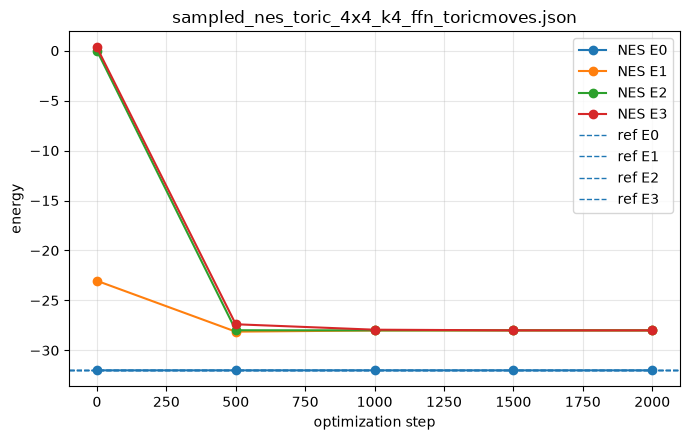

In [7]:
cfg = TrainConfig(
    shape=(4,4),
    hamiltonian="toric_code",
    k=4,
    optimizer = "adam",
    model="ffn",              
    hidden=(128,128,128),
    Je=1.0,
    Jm=1.0,
    init_scale=0.01,
    steps=2000,
    lr=5e-4,
    n_chains=128,
    n_samples=16,
    sweep_steps=64,
    burn_in=150,

    toric_loop_prob=0.05,
    toric_single_flip_prob=0,
    toric_cover_sectors=True,

    print_every=500,
    eval_exact_if_sites_leq=0,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=2,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k4_ffn_toricmoves.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

{'step': 0, 'optimizer': 'sr', 'lr': nan, 'loss_sum': -3.659517916825458e-05, 'train_energy_estimator': nan, 'energies': [-3.659517916825458e-05], 'reference': [-8.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [7.999963404820832], 'trace_error': 7.999963404820832, 'condition_number_S': 1.0, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'sr_update_norm': nan, 'sr_residual_norm': nan, 'eval': {'S_min_eig': 1.6962073914328357e-06, 'S_max_eig': 1.6962073914328357e-06, 'S_rank': 1, 'S_floor': 1e-06, 'S_num_clipped': 0, 'S_eigenvalues': [1.6962073914328357e-06], 'method': 'exact_span', 'accept_rate': None}, 'energy_matrix_eigvals': [-0.041992161279996706], 'state_energy_variances': [3.924976125644474], 'state_e

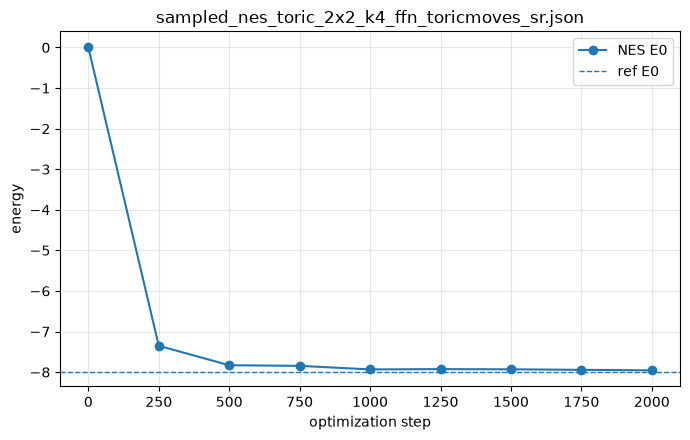

In [10]:
cfg = TrainConfig(
    shape=(2,2),
    hamiltonian="toric_code",
    k=1,
    optimizer = "sr",
    model="ffn",              
    hidden=(128,),
    Je=1.0,
    Jm=1.0,
    init_scale=0.01,
    steps=2000,
    lr=5e-1,
    n_chains=128,
    n_samples=32,
    sweep_steps=64,
    burn_in=320,

    toric_loop_prob=0.0,
    toric_single_flip_prob=0.1,
    toric_cover_sectors=False,

    print_every=250,
    eval_exact_if_sites_leq=14,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=2,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_2x2_k4_ffn_toricmoves_sr.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

{'step': 0, 'optimizer': 'sr', 'lr': nan, 'loss_sum': -4.1125624797525955, 'train_energy_estimator': nan, 'energies': [-3.9998946531367583, -0.11266782661583681], 'reference': [-5.226251859505506, -4.828427124746185], 'reference_source': 'netket_lanczos_ed', 'abs_errors': [1.226357206368748, 4.715759298130348], 'trace_error': 5.942116504499095, 'condition_number_S': 1600.1150943502266, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'sr_update_norm': nan, 'sr_residual_norm': nan, 'eval': {'S_min_eig': 5.7971922021585833e-08, 'S_max_eig': 0.0016001150943502265, 'S_rank': 1, 'S_floor': 1e-06, 'S_num_clipped': 1, 'S_eigenvalues': [5.7971922021585833e-08, 0.0016001150943502265], 'method': 'exact_span', 'accept_rate': None}, 'energy_matrix_eigvals

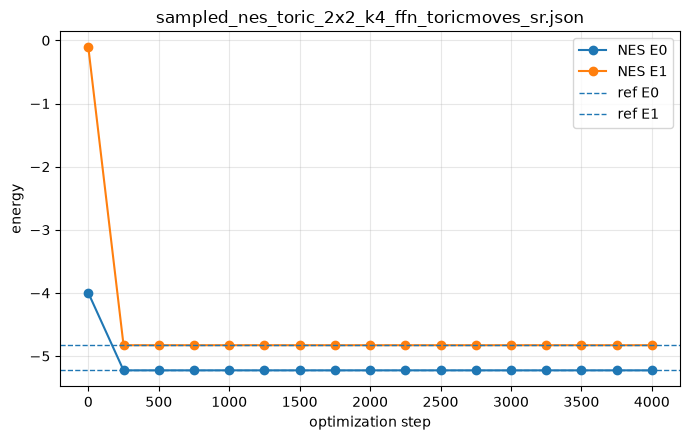

In [4]:
cfg = TrainConfig(
    shape=(2,2),
    hamiltonian="tfim",
    k=2,
    optimizer = "sr",
    model="ffn",              
    hidden=(64,),
    Je=1.0,
    Jm=1.0,
    init_scale=0.01,
    steps=4000,
    lr=5e-2,
    n_chains=128,
    n_samples=32,
    sweep_steps=64,
    burn_in=320,

    print_every=250,
    eval_exact_if_sites_leq=14,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=2,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_2x2_k4_ffn_toricmoves_sr.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

# conclusion: 
SR needs much larger learning rates compared to adam, largest for the toric code since it has a pretty flat energy landscape

{'step': 0, 'optimizer': 'sr', 'lr': nan, 'loss_sum': -4.000705246105938, 'train_energy_estimator': nan, 'energies': [-4.000648871998058, -5.6374107880609474e-05], 'reference': [-8.0, -8.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [3.9993511280019423, 7.9999436258921195], 'trace_error': 11.999294753894063, 'condition_number_S': 15346.978238020947, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'sr_update_norm': nan, 'sr_residual_norm': nan, 'eval': {'S_min_eig': 1.6680917005387023e-06, 'S_max_eig': 0.02560016702719082, 'S_rank': 2, 'S_floor': 1e-06, 'S_num_clipped': 0, 'S_eigenvalues': [1.6680917005387023e-06, 0.02560016702719082], 'method': 'exact_span', 'accept_rate': None}, 'energy_matrix_eigvals': [-

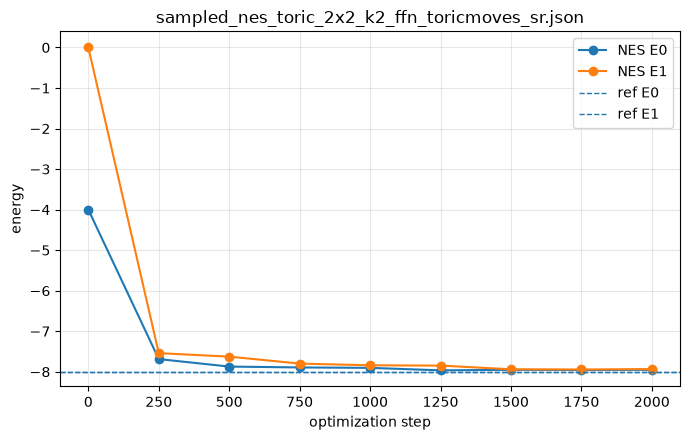

In [ ]:
cfg = TrainConfig(
    shape=(2,2),
    hamiltonian="toric_code",
    k=2,
    optimizer = "sr",
    model="ffn",              
    hidden=(128,),
    Je=1.0,
    Jm=1.0,
    init_scale=0.01,
    steps=2000,
    lr=5e-1,
    n_chains=128,
    n_samples=32,
    sweep_steps=64,
    burn_in=320,

    toric_loop_prob=0.1,
    toric_single_flip_prob=0.1,
    toric_cover_sectors=False,

    print_every=250,
    eval_exact_if_sites_leq=14,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=2,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_2x2_k2_ffn_toricmoves_sr.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

{'step': 0, 'optimizer': 'sr', 'lr': nan, 'loss_sum': -4.030904851432434, 'train_energy_estimator': nan, 'energies': [-4.001301600663548, -0.03184214011848077, -0.0006909185830805145, 0.0029298079326742056], 'reference': [-8.0, -8.0, -8.0, -8.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [3.998698399336452, 7.9681578598815195, 7.99930908141692, 8.002929807932674], 'trace_error': 27.969095148567565, 'condition_number_S': 265094.4437446379, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'sr_update_norm': nan, 'sr_residual_norm': nan, 'eval': {'S_min_eig': 1.35198618616568e-06, 'S_max_eig': 0.3584040259720254, 'S_rank': 4, 'S_floor': 1e-06, 'S_num_clipped': 0, 'S_eigenvalues': [1.35198618616568e-06, 2.1077057

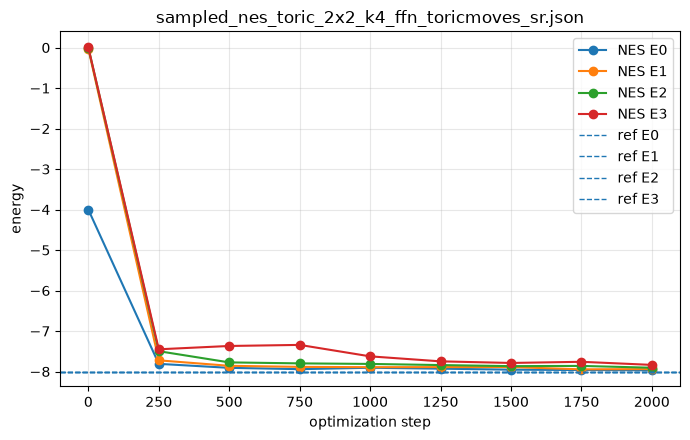

In [12]:
cfg = TrainConfig(
    shape=(2,2),
    hamiltonian="toric_code",
    k=4,
    optimizer = "sr",
    model="ffn",              
    hidden=(128,),
    Je=1.0,
    Jm=1.0,
    init_scale=0.01,
    steps=2000,
    lr=5e-1,
    n_chains=128,
    n_samples=32,
    sweep_steps=64,
    burn_in=320,

    toric_loop_prob=0.1,
    toric_single_flip_prob=0.1,
    toric_cover_sectors=False,

    print_every=250,
    eval_exact_if_sites_leq=14,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=2,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_2x2_k4_ffn_toricmoves_sr.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

{'step': 0, 'optimizer': 'sr', 'lr': nan, 'loss_sum': -4.004857788926805, 'train_energy_estimator': nan, 'energies': [-4.004006836471437, -0.03344602474608614, -0.012087874753365882, 0.0007433955793501081, 0.04393955146473341], 'reference': [-8.0, -8.0, -8.0, -8.0, -4.0], 'reference_source': 'toric_code_exact_4fold_ground_plus_first_excitation', 'abs_errors': [3.9959931635285626, 7.966553975253914, 7.987912125246634, 8.00074339557935, 4.043939551464733], 'trace_error': 31.995142211073194, 'condition_number_S': 768007.5705816111, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'sr_update_norm': nan, 'sr_residual_norm': nan, 'eval': {'S_min_eig': 3.3648871780282653e-07, 'S_max_eig': 0.7680075705816111, 'S_rank': 4, 'S_floor': 1e-06, 'S_num_clip

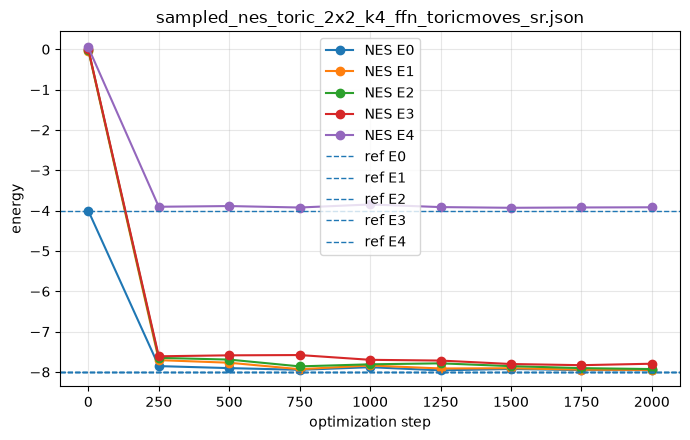

In [13]:
cfg = TrainConfig(
    shape=(2,2),
    hamiltonian="toric_code",
    k=5,
    optimizer = "sr",
    model="ffn",              
    hidden=(128,),
    Je=1.0,
    Jm=1.0,
    init_scale=0.01,
    steps=2000,
    lr=5e-1,
    n_chains=128,
    n_samples=32,
    sweep_steps=64,
    burn_in=320,

    toric_loop_prob=0.1,
    toric_single_flip_prob=0.1,
    toric_cover_sectors=False,

    print_every=250,
    eval_exact_if_sites_leq=14,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=2,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_2x2_k4_ffn_toricmoves_sr.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

{'step': 0, 'optimizer': 'sr', 'lr': nan, 'loss_sum': -11.830095202581907, 'train_energy_estimator': nan, 'energies': [-11.830095202581907], 'reference': [-32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [20.16990479741809], 'trace_error': 20.16990479741809, 'condition_number_S': 1.0, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'sr_update_norm': nan, 'sr_residual_norm': nan, 'eval': {'accept_rate': 0.58319091796875, 'burn_accept_rate': 0.5802246332168579, 'burn_loop_accept_rate': 0.0, 'burn_loop_move_fraction': 0.0, 'burn_single_flip_accept_rate': 0.7745364904403687, 'burn_single_flip_move_fraction': 0.0987548828125, 'burn_star_accept_rate': 0.5589327216148376, 'burn_star_move_fraction': 0.901245117187

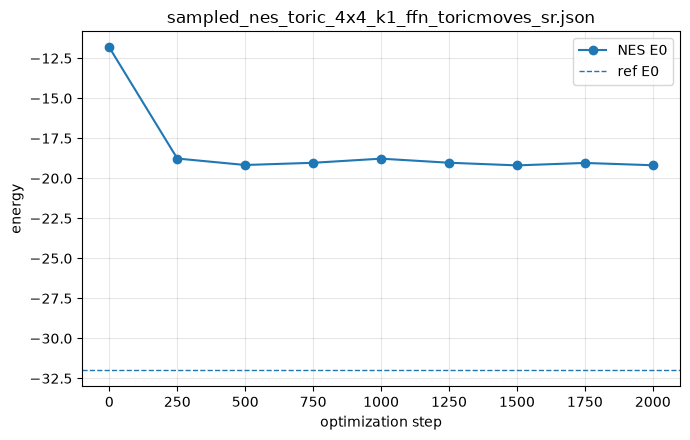

In [ ]:
cfg = TrainConfig(
    shape=(4,4),
    hamiltonian="toric_code",
    k=1,
    optimizer = "sr",
    model="ffn",              
    hidden=(128,),
    Je=1.0,
    Jm=1.0,
    init_scale=0.01,
    steps=2000,
    lr=0.1,
    n_chains=128,
    n_samples=32,
    sweep_steps=64,
    burn_in=320,

    toric_loop_prob=0,
    toric_single_flip_prob=0.1,
    toric_cover_sectors=True,

    print_every=250,
    eval_exact_if_sites_leq=14,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=2,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k1_ffn_toricmoves_sr.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.home() / 'Desktop' / 'Master Thesis' / 'NES_Spins'
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

import numpy as np
from nes_lattice.lattice import toric_code_move_masks, toric_code_plaquette_values
from nes_lattice.train import TrainConfig, train, save_history
from nes_lattice.plots import plot_history, plot_diagnostics, print_final


{'step': 0, 'optimizer': 'sr', 'lr': nan, 'loss_sum': -60.00016873715141, 'train_energy_estimator': nan, 'energies': [-32.000600551527796, -27.999568185623616], 'reference': [-32.0, -32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [0.0006005515277962559, 4.000431814376384], 'trace_error': 3.9998312628485877, 'condition_number_S': 241422.26612022342, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'sr_update_norm': nan, 'sr_residual_norm': nan, 'eval': {'accept_rate': 0.9984817504882812, 'burn_accept_rate': 0.998461902141571, 'burn_loop_accept_rate': 0.9980757236480713, 'burn_loop_move_fraction': 0.15224610269069672, 'burn_single_flip_accept_rate': 0.0, 'burn_single_flip_move_fraction': 0.0, 'burn_star_acce

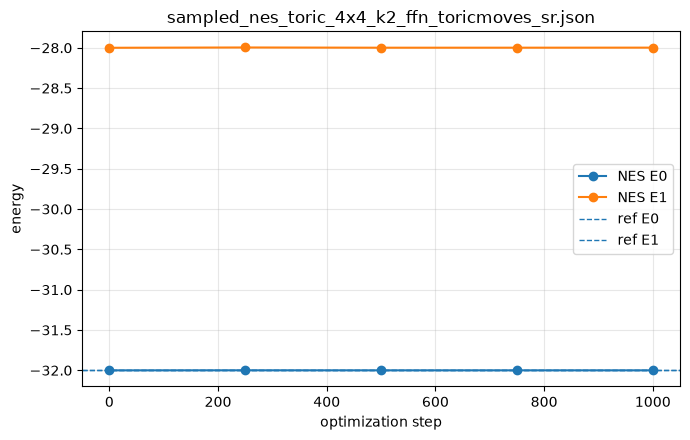

In [7]:
cfg = TrainConfig(
    shape=(4,4),
    hamiltonian="toric_code",
    k=2,
    optimizer = "sr",
    model="ffn",              
    hidden=(128,128),
    Je=1.0,
    Jm=1.0,
    init_scale=0.03,
    steps=1000,
    lr=0.1,
    n_chains=256,
    n_samples=64,
    sweep_steps=64,
    burn_in=128,

    toric_loop_prob=0.15,
    toric_single_flip_prob=0.0,
    toric_cover_sectors=False,

    print_every=250,
    eval_exact_if_sites_leq=14,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=2,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k2_ffn_toricmoves_sr.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

{'step': 0, 'optimizer': 'sr', 'lr': nan, 'loss_sum': -27.94084821177016, 'train_energy_estimator': nan, 'energies': [-16.02175580642907, -11.919092405341091], 'reference': [-32.0, -32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [15.97824419357093, 20.08090759465891], 'trace_error': 36.05915178822984, 'condition_number_S': 164963.6084561854, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'sr_update_norm': nan, 'sr_residual_norm': nan, 'eval': {'accept_rate': 0.998809814453125, 'burn_accept_rate': 0.9986572265625, 'burn_loop_accept_rate': 0.9982863068580627, 'burn_loop_move_fraction': 0.0997314453125, 'burn_single_flip_accept_rate': 0.9987192749977112, 'burn_single_flip_move_fraction': 0.30500489473342896

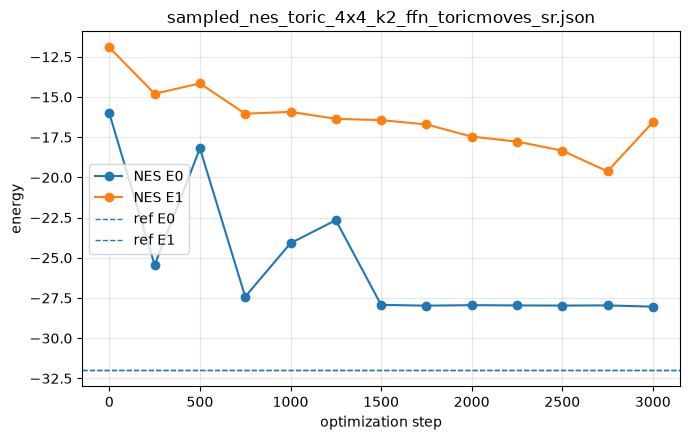

In [18]:
cfg = TrainConfig(
    shape=(4,4),
    hamiltonian="toric_code",
    k=2,
    optimizer = "sr",
    model="ffn",              
    hidden=(256,256),
    Je=1.0,
    Jm=1.0,
    init_scale=0.03,
    steps=3000,
    lr=0.5,
    n_chains=256,
    n_samples=64,
    sweep_steps=64,
    burn_in=128,

    toric_loop_prob=0.1,
    toric_single_flip_prob=0.3,
    toric_cover_sectors=False,

    print_every=250,
    eval_exact_if_sites_leq=14,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=2,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k2_ffn_toricmoves_sr.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

# True vs False

{'step': 0, 'optimizer': 'sr', 'lr': nan, 'loss_sum': -27.94084821177016, 'train_energy_estimator': nan, 'energies': [-16.02175580642907, -11.919092405341091], 'reference': [-32.0, -32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [15.97824419357093, 20.08090759465891], 'trace_error': 36.05915178822984, 'condition_number_S': 164963.6084561854, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'sr_update_norm': nan, 'sr_residual_norm': nan, 'eval': {'accept_rate': 0.998809814453125, 'burn_accept_rate': 0.9986572265625, 'burn_loop_accept_rate': 0.9982863068580627, 'burn_loop_move_fraction': 0.0997314453125, 'burn_single_flip_accept_rate': 0.9987192749977112, 'burn_single_flip_move_fraction': 0.30500489473342896

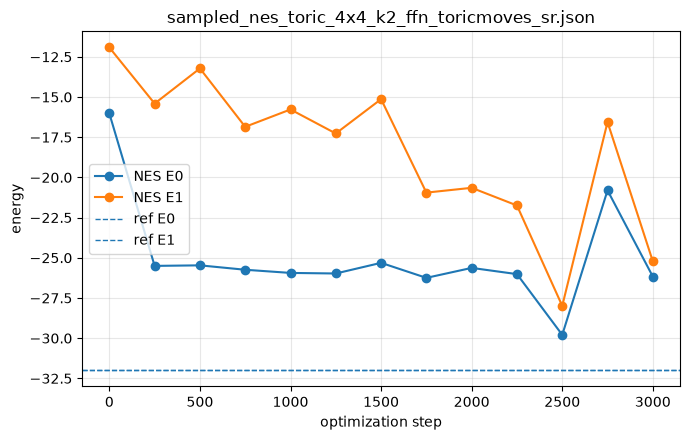

In [19]:
cfg = TrainConfig(
    shape=(4,4),
    hamiltonian="toric_code",
    k=2,
    optimizer = "sr",
    model="ffn",              
    hidden=(256,256),
    Je=1.0,
    Jm=1.0,
    init_scale=0.03,
    steps=3000,
    lr=0.5,
    n_chains=256,
    n_samples=64,
    sweep_steps=64,
    burn_in=128,

    toric_loop_prob=0.1,
    toric_single_flip_prob=0.3,
    toric_cover_sectors=True,

    print_every=250,
    eval_exact_if_sites_leq=14,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=2,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k2_ffn_toricmoves_sr.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

{'step': 0, 'optimizer': 'sr', 'lr': nan, 'loss_sum': -27.94084821177016, 'train_energy_estimator': nan, 'energies': [-16.02175580642907, -11.919092405341091], 'reference': [-32.0, -32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [15.97824419357093, 20.08090759465891], 'trace_error': 36.05915178822984, 'condition_number_S': 164963.6084561854, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'sr_update_norm': nan, 'sr_residual_norm': nan, 'eval': {'accept_rate': 0.998809814453125, 'burn_accept_rate': 0.9986572265625, 'burn_loop_accept_rate': 0.9982863068580627, 'burn_loop_move_fraction': 0.0997314453125, 'burn_single_flip_accept_rate': 0.9987192749977112, 'burn_single_flip_move_fraction': 0.30500489473342896

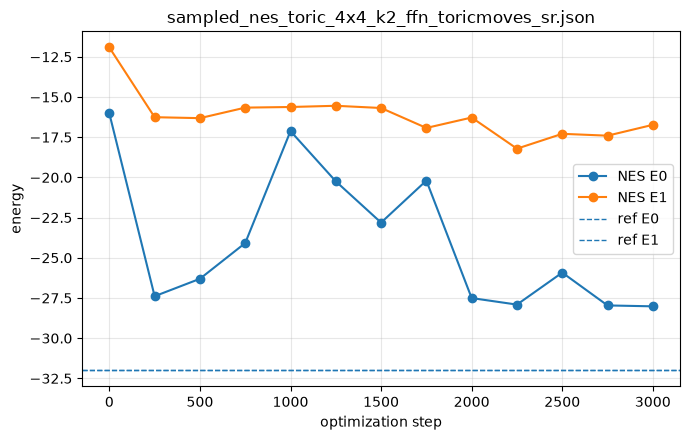

In [ ]:
cfg = TrainConfig(
    shape=(4,4),
    hamiltonian="toric_code",
    k=2,
    optimizer = "sr",
    model="ffn",              
    hidden=(256,256),
    Je=1.0,
    Jm=1.0,
    init_scale=0.03,
    steps=3000,
    lr=0.5,
    n_chains=128,
    n_samples=64,
    sweep_steps=64,
    burn_in=128,

    toric_loop_prob=0.1,
    toric_single_flip_prob=0.3,
    toric_cover_sectors=True,

    print_every=250,
    eval_exact_if_sites_leq=14,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=2,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k2_ffn_toricmoves_sr.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

{'step': 0, 'optimizer': 'sr', 'lr': nan, 'loss_sum': -28.14055533079503, 'train_energy_estimator': nan, 'energies': [-16.04182505790251, -12.098730272892523], 'reference': [-32.0, -32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [15.95817494209749, 19.901269727107476], 'trace_error': 35.85944466920497, 'condition_number_S': 7074.577745292594, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'sr_update_norm': nan, 'sr_residual_norm': nan, 'eval': {'accept_rate': 0.9947586059570312, 'burn_accept_rate': 0.993969738483429, 'burn_loop_accept_rate': 0.9914299249649048, 'burn_loop_move_fraction': 0.09970702975988388, 'burn_single_flip_accept_rate': 0.9972460865974426, 'burn_single_flip_move_fraction': 0.301416009

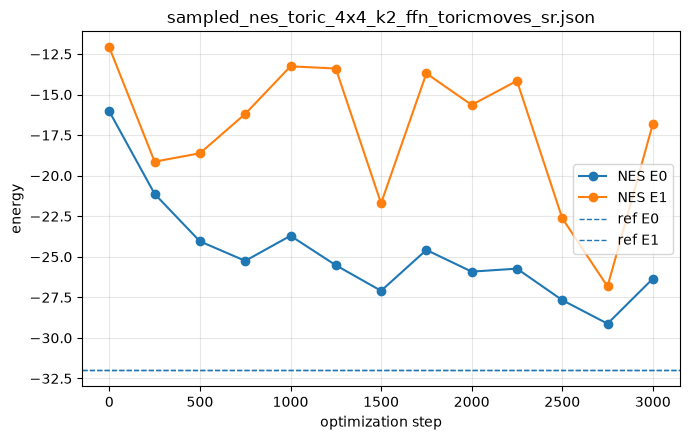

In [21]:
cfg = TrainConfig(
    shape=(4,4),
    hamiltonian="toric_code",
    k=2,
    optimizer = "sr",
    model="ffn",              
    hidden=(512,512),
    Je=1.0,
    Jm=1.0,
    init_scale=0.05,
    steps=3000,
    lr=0.5,
    n_chains=128,
    n_samples=64,
    sweep_steps=64,
    burn_in=128,

    toric_loop_prob=0.1,
    toric_single_flip_prob=0.3,
    toric_cover_sectors=True,

    print_every=250,
    eval_exact_if_sites_leq=14,   # temporary: evaluate in sampled flux-free sector
    reference="auto",
    seed=3,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k2_ffn_toricmoves_sr.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

In [4]:
for h in history:
    print(
        h["step"],
        "train:", h["train_energy_estimator"],
        "Ritz:", h["energies"],
        "variance:", h.get("state_energy_variances"),
        "condS:", h["condition_number_S"],
        "rank:", h["eval"].get("S_rank"),
        "SR residual:", h.get("sr_residual_norm"),
    )

0 train: nan Ritz: [-15.928467513932876, -11.953447891057607] variance: [17.028509797674925, 16.560418336856053] condS: 6384.025911699951 rank: 2 SR residual: nan
250 train: -40.9246940612793 Ritz: [-24.015187584912983, -19.369107378516674] variance: [12.268520977451438, 21.969004220092042] condS: 38.41468859370205 rank: 2 SR residual: 2.564565420150757
500 train: -44.042152404785156 Ritz: [-27.848535561779865, -21.58888218778295] variance: [1.3334141348965185, 19.511521011803843] condS: 19.869674300325183 rank: 2 SR residual: 0.6569296717643738
750 train: -44.51148986816406 Ritz: [-27.952582237789272, -21.658715043530467] variance: [0.4915459604847755, 24.140319456542862] condS: 76.30688961104039 rank: 2 SR residual: 0.28297293186187744
1000 train: -43.69808578491211 Ritz: [-28.295934635725953, -16.10857349639449] variance: [0.8730539200990791, 14.916764549851663] condS: 5197.209545601423 rank: 2 SR residual: 1.202544927597046
1250 train: -44.13043212890625 Ritz: [-30.80463091187177, 

{'step': 0, 'optimizer': 'sr', 'lr': nan, 'loss_sum': -27.881915404990483, 'train_energy_estimator': nan, 'energies': [-15.928467513932876, -11.953447891057607], 'reference': [-32.0, -32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [16.071532486067124, 20.046552108942393], 'trace_error': 36.11808459500952, 'condition_number_S': 6384.025911699951, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'sr_update_norm': nan, 'sr_residual_norm': nan, 'eval': {'accept_rate': 0.9926986694335938, 'burn_accept_rate': 0.9923340082168579, 'burn_loop_accept_rate': 0.9923881888389587, 'burn_loop_move_fraction': 0.05131835862994194, 'burn_single_flip_accept_rate': 0.9946860074996948, 'burn_single_flip_move_fraction': 0.05053

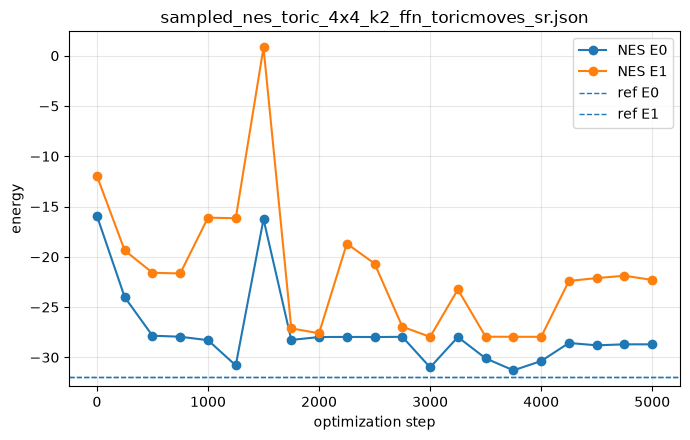

In [3]:
cfg = TrainConfig(
    shape=(4,4),
    hamiltonian="toric_code",
    k=2,
    optimizer = "sr",
    model="ffn",              
    hidden=(256,256),
    Je=1.0,
    Jm=1.0,
    init_scale=0.05,
    steps=5000,
    lr=0.15,
    n_chains=256,
    n_samples=64,
    sweep_steps=64,
    burn_in=128,

    toric_loop_prob=0.05,
    toric_single_flip_prob=0.05,
    toric_cover_sectors=True,

    print_every=250,
    eval_exact_if_sites_leq=14, 
    reference="auto",
    seed=3,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k2_ffn_toricmoves_sr.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

{'step': 0, 'optimizer': 'sr', 'lr': nan, 'loss_sum': -27.881915404990483, 'train_energy_estimator': nan, 'energies': [-15.928467513932876, -11.953447891057607], 'reference': [-32.0, -32.0], 'reference_source': 'toric_code_exact_4fold_ground_degeneracy', 'abs_errors': [16.071532486067124, 20.046552108942393], 'trace_error': 36.11808459500952, 'condition_number_S': 6384.025911699951, 'sampler_accept_rate': nan, 'sampler_star_accept_rate': nan, 'sampler_loop_accept_rate': nan, 'sampler_single_flip_accept_rate': nan, 'sampler_star_move_fraction': nan, 'sampler_loop_move_fraction': nan, 'sampler_single_flip_move_fraction': nan, 'invalid_bundle_fraction': nan, 'grad_norm': nan, 'sr_update_norm': nan, 'sr_residual_norm': nan, 'eval': {'accept_rate': 0.9926986694335938, 'burn_accept_rate': 0.9923340082168579, 'burn_loop_accept_rate': 0.9923881888389587, 'burn_loop_move_fraction': 0.05131835862994194, 'burn_single_flip_accept_rate': 0.9946860074996948, 'burn_single_flip_move_fraction': 0.05053

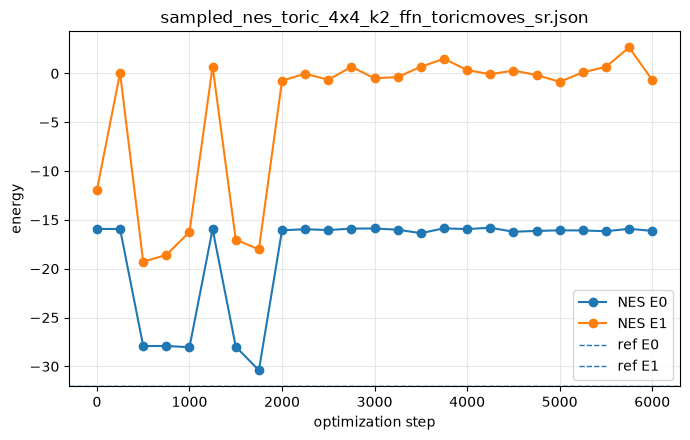

In [8]:
cfg = TrainConfig(
    shape=(4,4),
    hamiltonian="toric_code",
    k=2,
    optimizer = "sr",
    model="ffn",              
    hidden=(256,256),
    Je=1.0,
    Jm=1.0,
    init_scale=0.05,
    steps=6000,
    lr=0.15,
    n_chains=256,
    n_samples=64,
    sweep_steps=64,
    burn_in=128,

    toric_loop_prob=0.05,
    toric_single_flip_prob=0.05,
    toric_cover_sectors=True,
    
    sr_diag_shift=3e-3,
    sr_cg_iters=100,
    sr_cg_tol=1e-6,
    print_every=250,
    eval_exact_if_sites_leq=14, 
    reference="auto",
    seed=3,
)

params, history = train(cfg)
save_path = PROJECT_ROOT / 'results' / 'sampled_nes_toric_4x4_k2_ffn_toricmoves_sr.json'
save_history(history, save_path, cfg)
print_final(save_path)
fig, ax = plot_history(save_path)

In [7]:
for h in history:
    print(
        h["step"],
        "train:", h["train_energy_estimator"],
        "Ritz:", h["energies"],
        "variance:", h.get("state_energy_variances"),
        "condS:", h["condition_number_S"],
        "rank:", h["eval"].get("S_rank"),
        "SR residual:", h.get("sr_residual_norm"),
    )

0 train: nan Ritz: [-15.928467513932876, -11.953447891057607] variance: [17.028509797674925, 16.560418336856053] condS: 6384.025911699951 rank: 2 SR residual: nan
250 train: -33.83989715576172 Ritz: [-17.866254655784463, -16.09362310339021] variance: [15.685254273563952, 14.630976192343397] condS: 2.4914650302907626 rank: 2 SR residual: 6.08748722076416
500 train: -34.1380615234375 Ritz: [-18.551484462696198, -16.073267583487514] variance: [16.481797178854546, 14.365178175065804] condS: 3.9340495075781257 rank: 2 SR residual: 7.828124046325684
750 train: -34.62411880493164 Ritz: [-18.82548471969449, -15.844879735689286] variance: [15.869947419186705, 14.067209516362945] condS: 7.958839767652731 rank: 2 SR residual: 17.437288284301758
1000 train: -34.82564163208008 Ritz: [-19.32215830491157, -16.04979393120557] variance: [15.351044299877415, 13.594779358941238] condS: 11.768971809218906 rank: 2 SR residual: 22.222091674804688
1250 train: -35.02690505981445 Ritz: [-19.07553477076886, -15